## Colab 환경에서 실행 시 환경 설정

In [ ]:
# 구글 드라이브의 폴더와 구글 코랩 폴더 연결
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# 현재 경로 확인
!pwd

In [ ]:
# drive/MyDrive/Colab Notebooks 경로로 변경
%cd drive/MyDrive/'Colab Notebooks'

#### 코랩에서 한국어 표시하기

In [ ]:
!apt-get install fonts-nanum* -qq
# 다운받은 후 코랩 런타임 다시 시작

In [ ]:
%matplotlib inline
# 별도의 plt.show()를 호출하지 않아도 그래프가 노트북 내부에 자동으로 출력됨
import matplotlib.pyplot as plt
import matplotlib as mpl 

plt.rcParams['axes.unicode_minus'] = False # 마이너스 부호 패치
path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_name = mpl.font_manager.FontProperties(fname=path).get_name()
plt.rcParams['font.family'] = font_name

# 🔖 PyTorch를 활용한 DNN 복습 및 합성곱 신경망

<a id="lecture_index"></a>
## 수업 목차

[1. PyTorch를 활용한 심층신경망 복습 및 심장병 예측 DNN 모델 학습하기(Kaggle)](#one)<br>
- 지난주 내용 복습 
- 심장병 예측 DNN 실습

[2. DNN의 한계](#two)<br>
- DNN이 갖는 구조적 한계
- Quiz1

[3. 시각처리 딥러닝의 시작](#three)<br>
- 인간의 시각처리 방식 
- LeNet-5 구조 이해하기 
- Mnist 데이터 셋을 활용한 LeNet-5 모델 학습 
- Quiz2

[4. 합성곱 신경망 (CNN)](#four)<br>
- CNN의 기본 구조 
- CNN 모델을 활용한 FashionMNIST 데이터 학습
- Quiz3

[5. CNN을 이루는 구성 요소들](#five)<br>
- 필터(Filter)와 커널(Kernel)
- 합성곱 연산 (Convolution)
- 수용 영역 (Receptive Field)
- 스트라이드 (Stride)
- 패딩 (Padding)
- 피처맵 (Feature map)
- 채널 (Channel)
- 풀링 연산 (Pooling)
- Quiz4

[6. CNN의 한계](#six)<br>
- CNN의 한계 
- Quiz5

## <a id='one'>1️⃣ PyTorch를 활용한 심층신경망 복습 및 심장병 예측 DNN 모델 학습하기(Kaggle)</a><br>

<a href="#lecture_index">
    <span>⬆ 목차로</span>
</a>

## 지난주 내용 복습

> PyTorch는 딥러닝 연구를 쉽게 할 수 있게 만들어진 딥러닝 프레임워크 <br> 
> PyTorch의 대표적인 4가지 특징 <br> 

- 동적 계산 그래프
- 직관적인 문법 
- GPU 지원 
- 자동 미분 

```
핵심 요소 정리 

텐서 속성 확인 방법 4가지 
- shape
- dtype 
- device 
- dim 

텐서 인덱싱 및 슬라이싱 연산 5가지 방법 
- i번째 요소 접근 
- i행, j열 요소 접근 
- i부터 j-1까지 슬라이싱 i:j 
- 모든 행 또는 모든 열 : 
- mask  

텐서 변환 연산 5가지 
- view 
- reshape 
- permute 
- transpose 
- squeeze 

행렬 연산 4가지 
- matmul
- mm
- bmm
- t 
```

In [45]:
import torch 

a = torch.tensor([
    [[1, 2], [4, 3], [7, 4]],  
    [[2, 0], [9, 0], [7, 5]],  
    [[1, 0], [3, 0], [0, 2]],  
    [[9, 0], [6, 0], [9, 8]]  
])

In [50]:
a[0]

tensor([[1, 2],
        [4, 3],
        [7, 4]])

In [49]:
a[2, 1, :]

tensor([3, 0])

## [Kaggle] Heart Disease Predictions

In [59]:
import pandas as pd 
import missingno as msno

heart_data = pd.read_csv('data/heart.csv')

In [60]:
heart_data['ca'].value_counts()

ca
0    175
1     65
2     38
3     20
4      5
Name: count, dtype: int64

In [61]:
heart_data['thal'].value_counts()

thal
2    166
3    117
1     18
0      2
Name: count, dtype: int64

### EDA 

In [62]:
'''
age: 나이
sex: 성별  (1: 남성, 0: 여성)
cp: 가슴 통증 유형  (0: 전형적인 협심증, 1: 비정형 협심증, 2: 비협심증 통증, 3: 무증상)
trestbps: 안정 혈압 (mmHg)
chol: 콜레스테롤 수치  (mg/dl)
fbs: 공복 혈당 수치 (120 mg/dl 이상이면 1, 그렇지 않으면 0)
restecg: 안정 심전도 결과  (0: 정상, 1: 이상, 2: 좌심실 비대)
thalach: 최대 심박수 (bpm)
exang: 운동 유발 협심증 여부 (1: 유발, 0: 비유발)
oldpeak: 휴식과 관련된 운동의 ST segment depression (ST segment의 감소)
slope: 피크 운동 ST segment의 기울기 (0: 하강, 1: 평평, 2: 상승) / 하강 -> 상승 : 심장병 위험도 감소
ca: 형광 투시법으로 색칠된 주요 혈관의 수(관상동맥) (0-3)  / 관상동맥 -> 심장에 혈액을 공급하는 혈관 / 사람은 최대 3개까지 가질 수 있음 (좌전하행동맥, 좌회선동맥, 우관상동맥)
thal: thalassemia의 종류 (1: 정상 2: 결함 있음 3: 가역적 결함)  / 2: 과거 심근경색 경험 가능성 높음 3: 현재 관상동맥이 좁아 졌거나 허혈 발생 가능성 
target: 심장병 진단 여부 (0: 정상, 1: 심장병)

값 0: 혈관이 50% 미만으로 좁아진 상태 → 심각한 협착(협심증 등)이 아닐 가능성이 큼
값 1: 혈관이 50% 이상 좁아진 상태 → 의미 있는 협착이 있으며, 심장 질환(예: 관상동맥 질환, 협심증 등) 가능성이 높음

데이터 #93, 159, 164, 165, 252는 ca(관상동맥 수) 값이 4로 되어 있는데, 
이는 잘못된 값이다. 원래 Cleveland 데이터셋에서는 NaN(결측값) 이었다.

데이터 #49, 282는 thal(탈륨 검사 결과) 값이 0으로 되어 있는데, 이 또한 잘못된 값이다. 
원래 Cleveland 데이터셋에서는 NaN(결측값) 이었다.

조치: 잘못된 데이터 7개를 삭제해야 한다!
'''

heart_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [63]:
# 데이터 imbalance 확인 
heart_data['target'].value_counts()

target
1    165
0    138
Name: count, dtype: int64

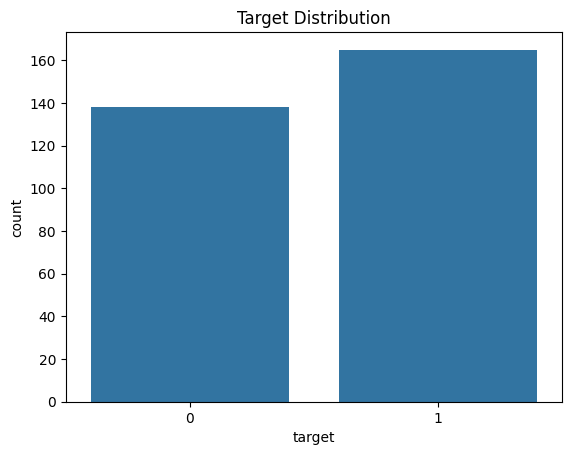

In [64]:
import seaborn as sns

sns.countplot(data=heart_data, x='target')
plt.title('Target Distribution')
plt.show()

In [65]:
# 대략적인 분포 확인 
heart_data.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [66]:
heart_data['ca'].value_counts()

ca
0    175
1     65
2     38
3     20
4      5
Name: count, dtype: int64

In [67]:
heart_data['thal'].value_counts()

thal
2    166
3    117
1     18
0      2
Name: count, dtype: int64

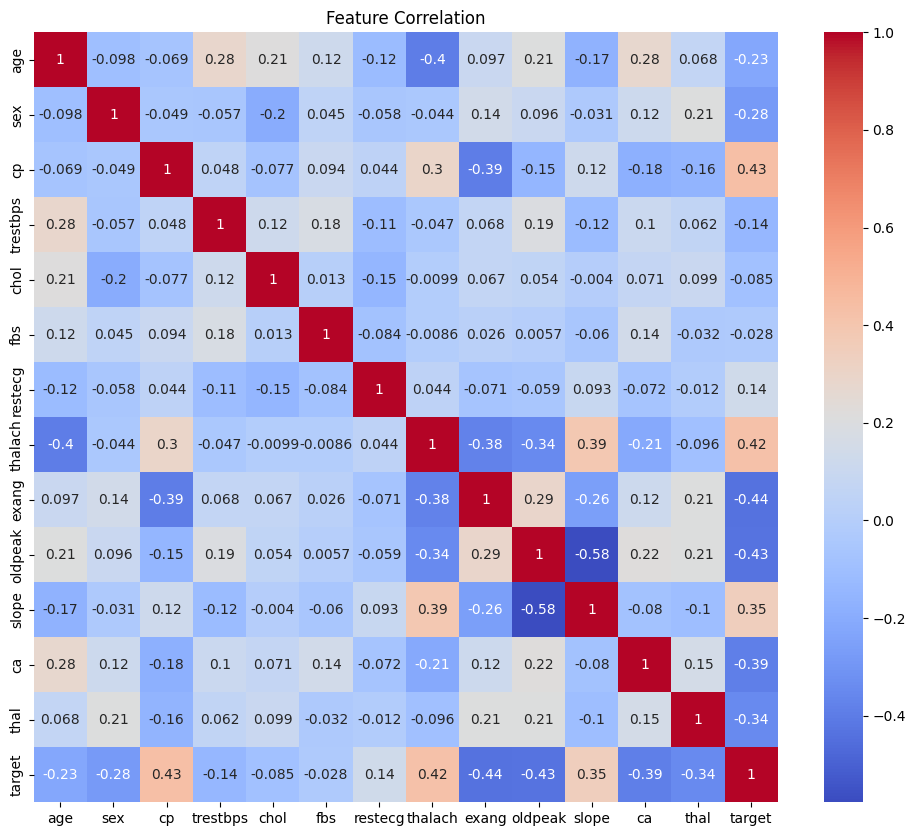

In [68]:
# 상관관계 
plt.figure(figsize=(12,10))
sns.heatmap(heart_data.corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation')
plt.show()

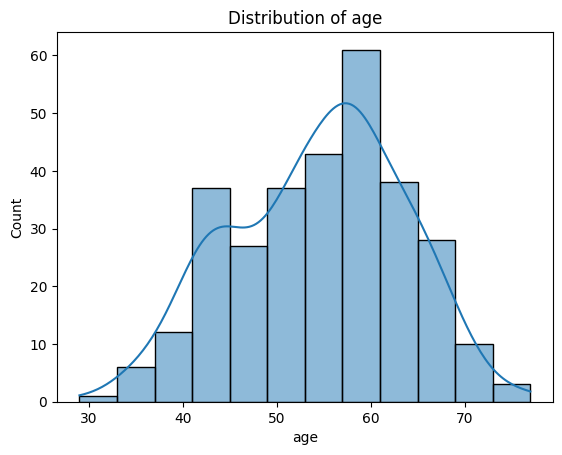

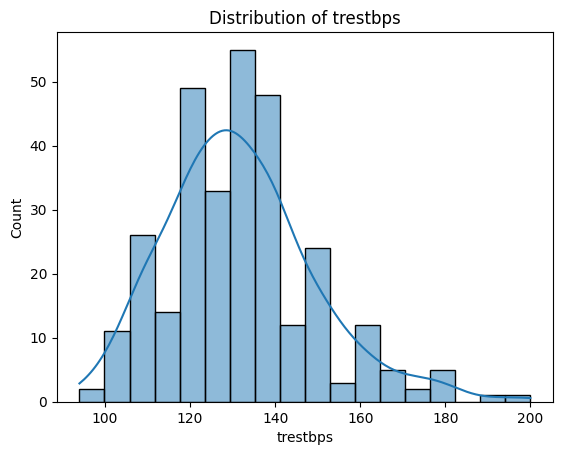

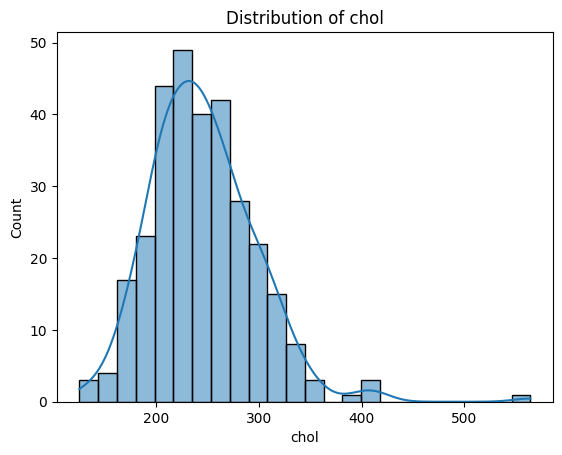

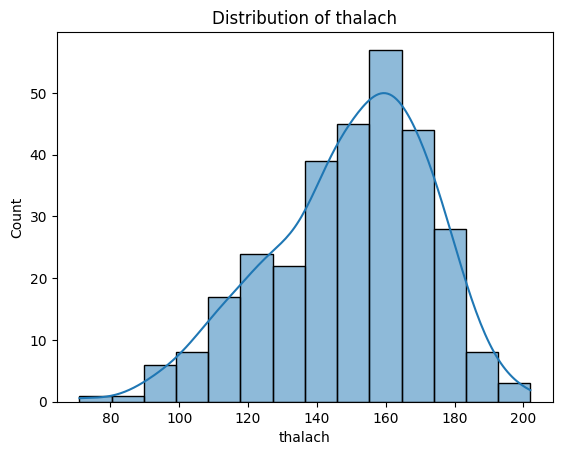

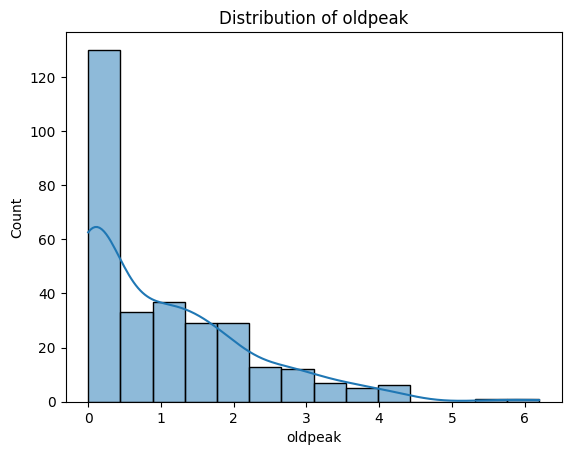

In [69]:
# 분포 시각화 (연속형 변수 중심)
num_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
for col in num_cols:
    sns.histplot(data=heart_data, x=col, kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

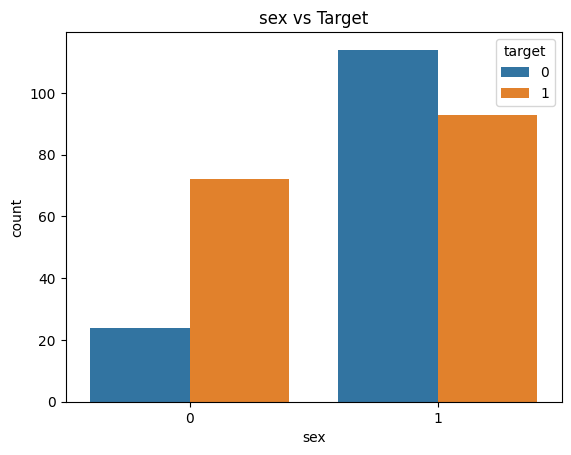

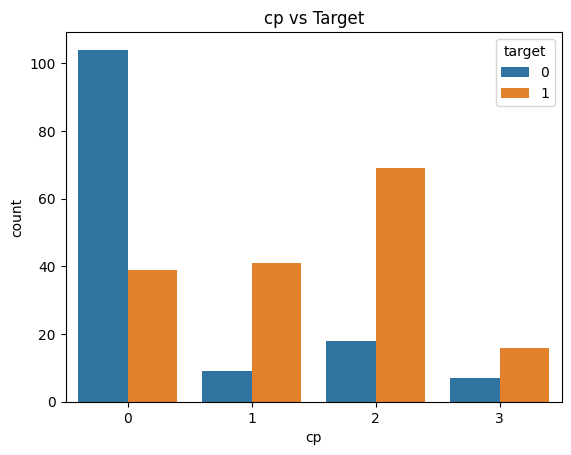

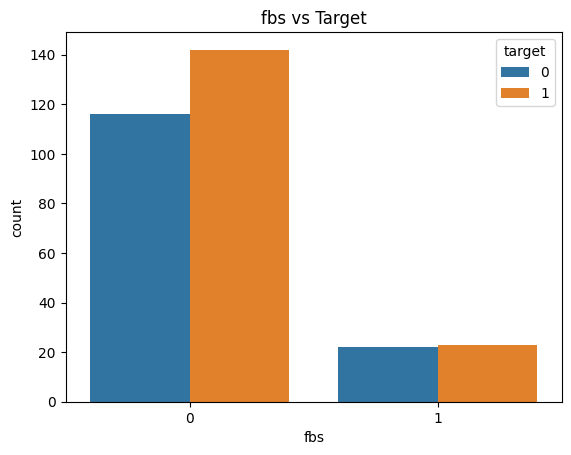

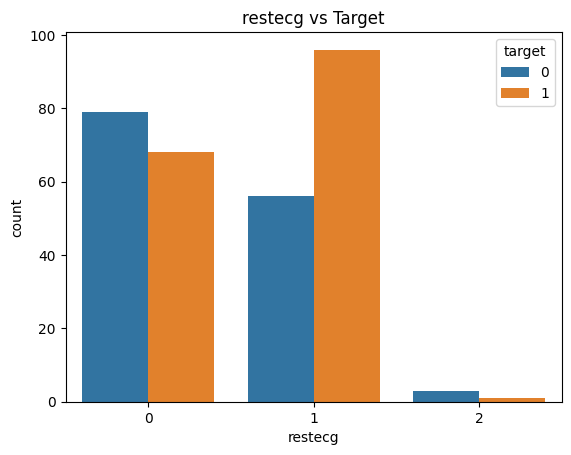

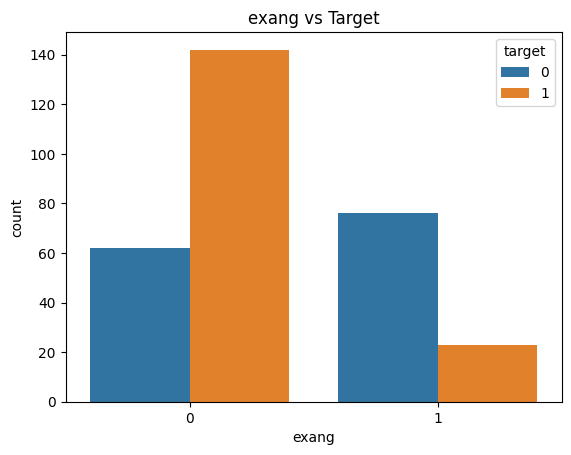

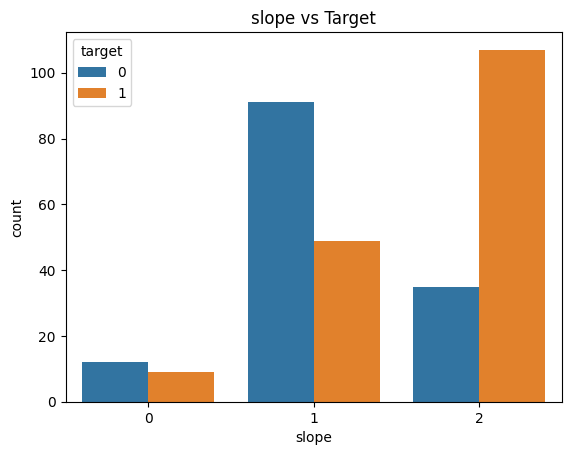

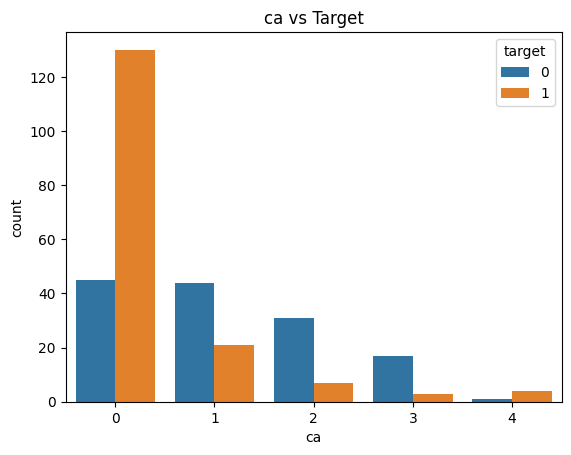

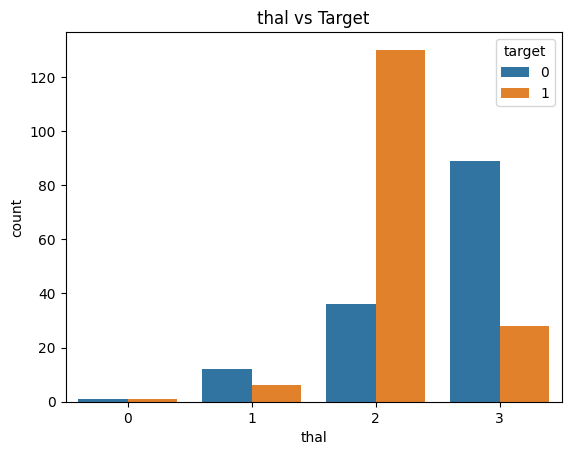

In [70]:
# 범주형 변수 시각화
cat_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
for col in cat_cols:
    sns.countplot(data=heart_data, x=col, hue='target')
    plt.title(f'{col} vs Target')
    plt.show()

### 결측치 처리 및 이상치 제거 

<Axes: >

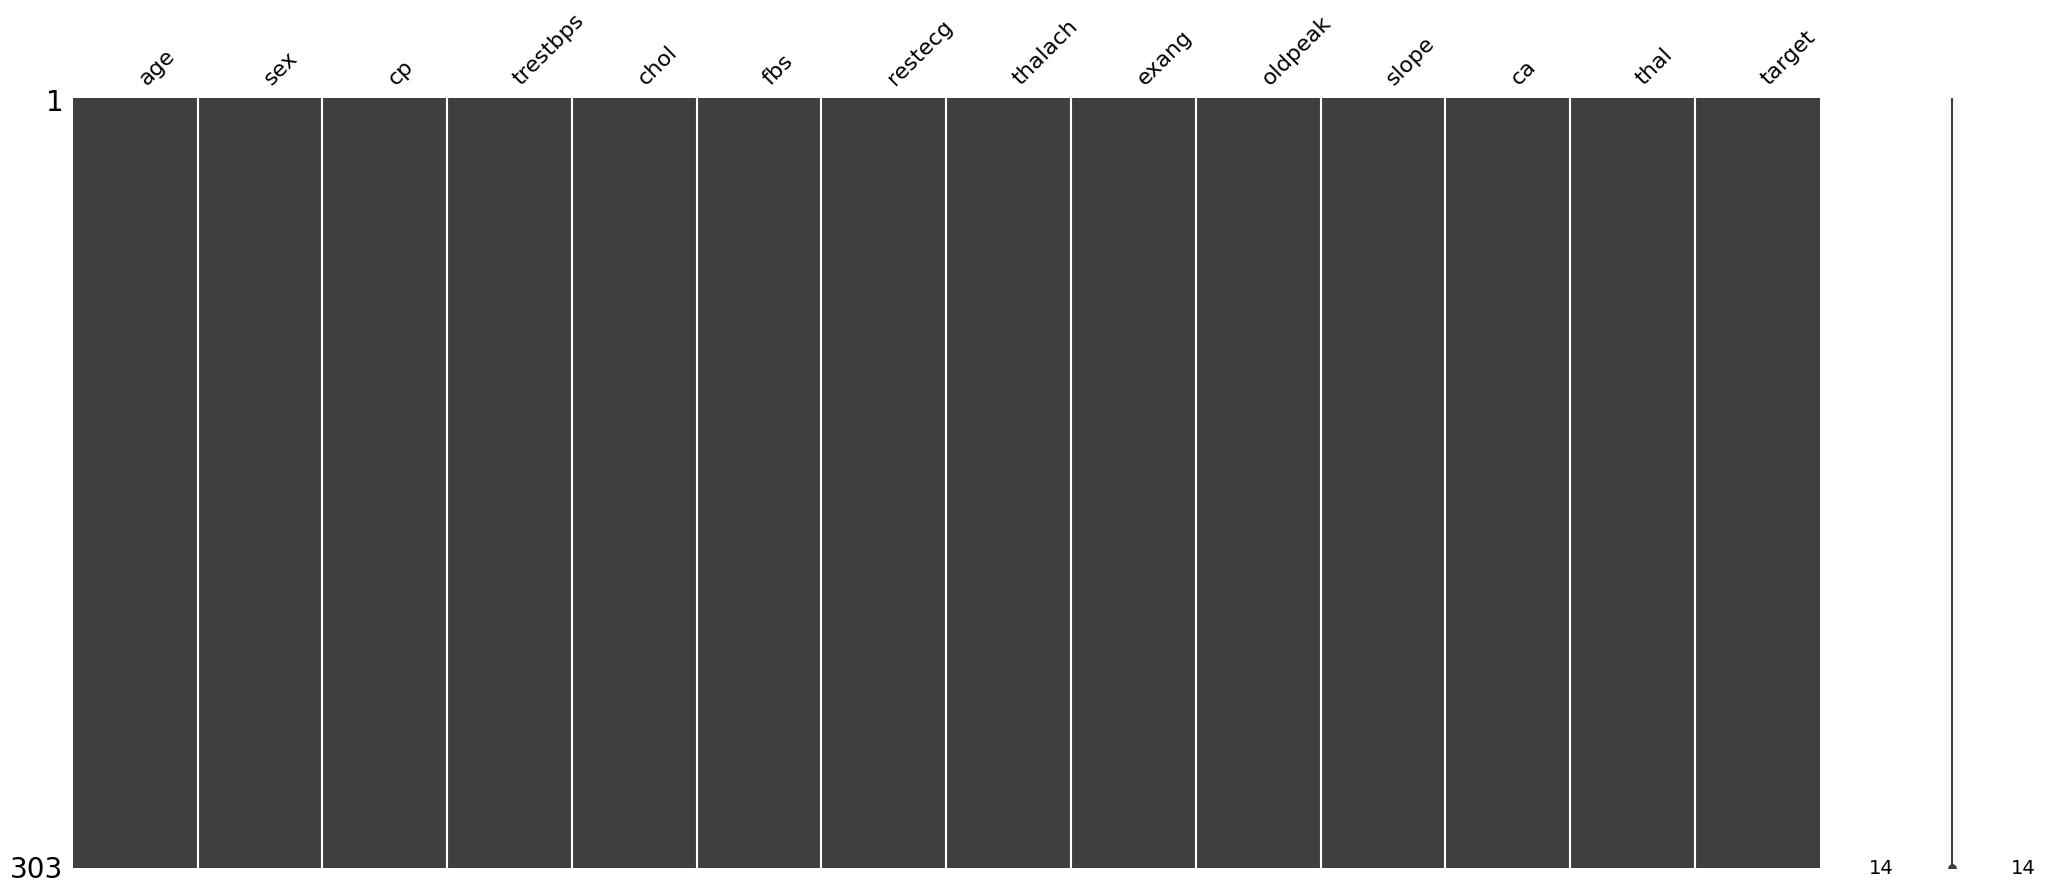

In [71]:
msno.matrix(heart_data)

In [72]:
heart_data['ca'].value_counts() # 4 값은 이상치(있을 수 없는 수) -> 제거 

ca
0    175
1     65
2     38
3     20
4      5
Name: count, dtype: int64

In [73]:
heart_data['thal'].value_counts() # 0 값은 이상치(있을 수 없는 수) -> 제거 

thal
2    166
3    117
1     18
0      2
Name: count, dtype: int64

In [74]:
len(heart_data)

303

In [75]:
heart_data = heart_data[heart_data['ca'] != 4]
heart_data = heart_data[heart_data['thal'] != 0]

In [76]:
len(heart_data)

296

### 데이터 전처리

In [125]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# 입력 데이터 타겟 데이터 분리 
X = heart_data.drop('target', axis=1) 
y = heart_data['target']

In [126]:
heart_data.columns[heart_data.nunique() == 2]

Index(['sex', 'fbs', 'exang', 'target'], dtype='object')

In [127]:
# 범주형 데이터 중에 순서가 의미가 없는 데이터는 one-hot encoding, 연속형 데이터는 표준화
# 단, 이진 변수의 경우는 one-hot encoding에서 제외 
numeric_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
categorical_features = ['cp', 'restecg', 'slope', 'ca', 'thal']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(), categorical_features)
])

prepro_X = preprocessor.fit_transform(X)

In [128]:
heart_data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [129]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(prepro_X, y, test_size=0.2, random_state=42)

In [130]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((236, 22), (236,), (60, 22), (60,))

In [131]:
y_train.to_numpy().shape

(236,)

In [132]:
y_train.to_numpy().shape

(236,)

In [134]:
from torch.utils.data import DataLoader, TensorDataset

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.to_numpy(), dtype=torch.float32).unsqueeze(1) #  (batch_size, 1) 형태로 변환

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.to_numpy(), dtype=torch.float32).unsqueeze(1) #  (batch_size, 1) 형태로 변환

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

In [135]:
img, label = next(iter(train_loader))

In [136]:
X_train_tensor.shape, y_train_tensor.shape, X_test_tensor.shape, y_test_tensor.shape

(torch.Size([236, 22]),
 torch.Size([236, 1]),
 torch.Size([60, 22]),
 torch.Size([60, 1]))

In [137]:
from torch import nn, optim

#  DNN 모델 정의
class HeartDNN(nn.Module):
    def __init__(self):
        super(HeartDNN, self).__init__()
        # self.fc1 = nn.Linear(22, 64)
        # self.fc2 = nn.Linear(64, 32)
        # self.fc3 = nn.Linear(32, 16)
        # self.fc4 = nn.Linear(16, 1)
        self.fc1 = nn.Linear(22, 32) # fc: Fully connected 
        self.fc2 = nn.Linear(32, 16)
        self.fc3 = nn.Linear(16, 1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        self.dropout = nn.Dropout(0.3) # 30% 
        
    def forward(self, x):
        # x = self.relu(self.fc1(x))
        # x = self.dropout(x)
        # x = self.relu(self.fc2(x))
        # x = self.dropout(x)
        # x = self.relu(self.fc3(x))
        # x = self.dropout(x)
        # x = self.fc4(x)
        x = self.relu(self.fc1(x)) # relu 활성화 함수 -> 비선형성을 주기 위해서 
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        x = self.sigmoid(x) # 예측값을 확률로 출력할 수 있게 유도 
        return x

model = HeartDNN()
bce = nn.BCELoss()  # Binary Cross Entropy Loss -> 이진 분류 문제에 사용하는 손실함수 -> 입력값은 확률 값으로 넣어야 함
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [138]:
epochs = 150
train_losses = []

for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    for X_batch, y_batch in train_loader:
        y_pred = model(X_batch)
        loss = bce(y_pred, y_batch)
        optimizer.zero_grad() # 기울기 초기화 
        loss.backward() # backpropagation -> 미분값 계산 
        optimizer.step() # 가중치 업데이트 
        epoch_loss += loss.item()
    train_losses.append(epoch_loss / len(train_loader))

    if (epoch+1) % 10 == 0:
        print(f'Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}')

Epoch 10/150, Loss: 2.6191
Epoch 20/150, Loss: 1.8141
Epoch 30/150, Loss: 1.3357
Epoch 40/150, Loss: 1.4939
Epoch 50/150, Loss: 1.1332
Epoch 60/150, Loss: 0.8474
Epoch 70/150, Loss: 0.7553
Epoch 80/150, Loss: 0.6845
Epoch 90/150, Loss: 0.6633
Epoch 100/150, Loss: 1.0269
Epoch 110/150, Loss: 0.8356
Epoch 120/150, Loss: 0.6825
Epoch 130/150, Loss: 0.5472
Epoch 140/150, Loss: 0.8446
Epoch 150/150, Loss: 0.4918


In [139]:
from sklearn.metrics import classification_report, confusion_matrix

model.eval()
with torch.no_grad():
    y_pred_prob = model(X_test_tensor)
    y_pred = (y_pred_prob > 0.5).float()
    
print("Confusion Matrix:")
print(confusion_matrix(y_test_tensor, y_pred))
print("\nClassification Report:")
print(classification_report(y_test_tensor, y_pred))

# 정확도 시각화
acc = (y_pred == y_test_tensor).float().mean().item()
print(f"Test Accuracy: {acc * 100:.2f}%")

Confusion Matrix:
[[25  3]
 [ 9 23]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.74      0.89      0.81        28
         1.0       0.88      0.72      0.79        32

    accuracy                           0.80        60
   macro avg       0.81      0.81      0.80        60
weighted avg       0.81      0.80      0.80        60

Test Accuracy: 80.00%


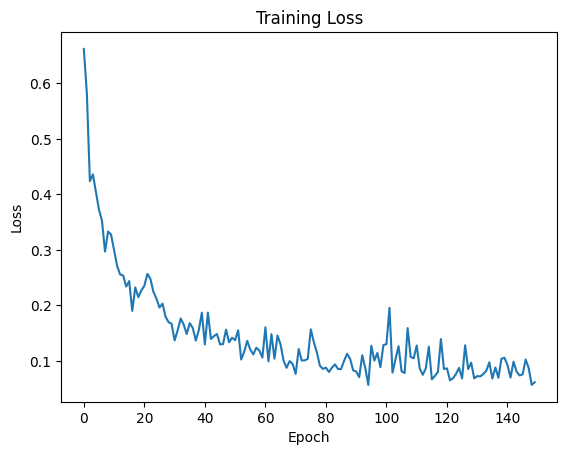

In [140]:
import matplotlib.pyplot as plt

plt.plot(train_losses)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

### KFold

In [141]:
import numpy as np 
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold

In [142]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold = 1
all_fold_accuracies = []

In [143]:
for train_idx, val_idx in kf.split(prepro_X):
    print(f"\n[Fold {fold}] -------------------------------")

    # 데이터 분할
    X_train, X_val = prepro_X[train_idx], prepro_X[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]    # 중간에 이상치를 제거했기 때문에 인덱스 라벨이 아닌 행 번호로 가져오기

    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train.to_numpy(), dtype=torch.float32).unsqueeze(1)

    X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val.to_numpy(), dtype=torch.float32).unsqueeze(1)

    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=32)
    
    model = HeartDNN()
    bce = nn.BCELoss() 
    optimizer = optim.Adam(model.parameters(), lr=0.01)
    
    for epoch in range(150):
        model.train()
        for X_batch, y_batch in train_loader:
            y_pred = model(X_batch)
            loss = bce(y_pred, y_batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
    
    model.eval()
    with torch.no_grad():
        y_val_logits = model(X_val_tensor)
        y_val_probs = torch.sigmoid(y_val_logits)
        y_val_pred = (y_val_probs > 0.5).float()
        acc = accuracy_score(y_val_tensor.numpy(), y_val_pred.numpy())
        print(f"Fold {fold} Accuracy: {acc:.4f}")
        all_fold_accuracies.append(acc)
        fold += 1


[Fold 1] -------------------------------
Fold 1 Accuracy: 0.8167

[Fold 2] -------------------------------
Fold 2 Accuracy: 0.8814

[Fold 3] -------------------------------
Fold 3 Accuracy: 0.6610

[Fold 4] -------------------------------
Fold 4 Accuracy: 0.7119

[Fold 5] -------------------------------
Fold 5 Accuracy: 0.7288


In [144]:
print("K-Fold 평균 정확도:", np.mean(all_fold_accuracies))

K-Fold 평균 정확도: 0.7599435028248587


### 정확도가 들쭉날쭉한 이유는? 

1. 데이터 수가 적음 
2. 데이터 수에 비해 모델이 복잡해서 과적합 된 경우

In [146]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

heart_data = pd.read_csv('data/heart.csv')

heart_data = heart_data[heart_data['ca'] != 4]
heart_data = heart_data[heart_data['thal'] != 0]

# 입력 데이터 타겟 데이터 분리 
X = heart_data.drop('target', axis=1) 
y = heart_data['target']

numeric_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
categorical_features = ['cp', 'restecg', 'slope', 'ca', 'thal']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(), categorical_features)
])

In [147]:
from sklearn.pipeline import Pipeline

from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

param_grid = {
    "Logistic Regression": {
        "model": LogisticRegression(),
        "params": {
            "classifier__C": [0.01, 0.1, 1, 10]
        }
    },
    "Random Forest": {
        "model": RandomForestClassifier(),
        "params": {
            "classifier__n_estimators": [50, 100],
            "classifier__max_depth": [None, 5, 10]
        }
    },
    "SVM": {
        "model": SVC(probability=True),
        "params": {
            "classifier__C": [0.1, 1, 10],
            "classifier__kernel": ['linear', 'rbf']
        }
    },
    "KNN": {
        "model": KNeighborsClassifier(),
        "params": {
            "classifier__n_neighbors": [3, 5, 7]
        }
    },
    "XGBoost": {
        "model": XGBClassifier(eval_metric='logloss'),
        "params": {
            "classifier__n_estimators": [50, 100],
            "classifier__max_depth": [3, 5],
            "classifier__learning_rate": [0.01, 0.1]
        }
    }
}


results = []
for name, config in param_grid.items():
    pipeline = Pipeline([
        ("preprocessing", preprocessor),
        ("classifier", config['model'])
    ])
    
    grid = GridSearchCV(pipeline, config["params"], cv=5, scoring="accuracy", n_jobs=-1)
    grid.fit(X, y)
    
    scores = cross_val_score(pipeline, X, y, cv=5, scoring="accuracy")
    results.append({
        "Model": name,
        "Best Accuracy": grid.best_score_,
        "Best Params": grid.best_params_
    })

In [148]:
results_df = pd.DataFrame(results).sort_values(by="Best Accuracy", ascending=False)
results_df

,Model,Best Accuracy,Best Params
2,SVM,0.847910,"{'classifier__C': 1, 'classifier__kernel': 'li..."
0,Logistic Regression,0.837740,{'classifier__C': 10}
1,Random Forest,0.831130,"{'classifier__max_depth': None, 'classifier__n..."
4,XGBoost,0.814181,"{'classifier__learning_rate': 0.1, 'classifier..."
3,KNN,0.810847,{'classifier__n_neighbors': 5}


## <a id='two'>2️⃣ DNN의 한계</a><br>

<a href="#lecture_index">
    <span>⬆ 목차로</span>
</a>

## DNN이 갖는 구조적 한계

참고: https://www.youtube.com/watch?v=aircAruvnKk&list=PLZHQObOWTQDNU6R1_67000Dx_ZCJB-3pi

#### ✅ 고차원 입력 데이터 처리의 비효율성 
- 가중치 개수가 이미지 크기에 따라 기하 급수적으로 늘어남
- 이미지 데이터를 학습할때 CNN모델로 학습하는 것 보다 더 많은 파라미터가 필요  
#### ✅ 과적합 
- 파라미터 수가 많아지면 훈련 데이터에 과도하게 적응하게 됨 
#### ✅ 기울기 소실 문제
- 같은 layer 층을 쌓더라도 CNN 구조보다 기울기 소실 문제가 더 빠르게 발생할 수 있음 
  (Receptive Field 구조로 인해 CNN은 정보가 좀 더 점진적으로 전달됨)

#### ✅ 공간적 정보 소실 
- 2차원 데이터를 1차원 데이터로 펼쳐서 처리하면 인접한 데이터간의 상관관계가 사라진다
- 위치 정보가 사라짐

<img src="사진/flatten.png" width=600 height=350 alt="flatten"/>

#### ✅ 위치 변화에 민감 (Lake of Translation invariance)
- 같은 물체라도 위치가 달라지면 전혀 다른 것으로 인식하는 문제 

<img src="사진/dnn_limit.png" width=600 height=350 alt="dnn_limit"/>

### 위치 변화에 민감한 DNN 모델 (예제)

In [149]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np
from scipy.ndimage import shift
import matplotlib.pyplot as plt

# 1. 하이퍼파라미터
BATCH_SIZE = 128
EPOCHS = 5
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. 데이터 전처리
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset_original = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader_original = DataLoader(test_dataset_original, batch_size=BATCH_SIZE, shuffle=False)

# 3. DNN 모델 정의 (Flatten → FC 128 → FC 10)
class DNN(nn.Module):
    def __init__(self):
        super(DNN, self).__init__()
        self.fc1 = nn.Linear(28*28, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = x.view(-1, 28*28)  # Flatten
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = DNN().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

# 4. 학습
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

# 5. 테스트 정확도 함수
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return correct / total

# 6. 원본 테스트셋 정확도
acc_original = evaluate(model, test_loader_original)
print(f" 원본 테스트셋 정확도: {acc_original:.4f}")

Epoch 1, Loss: 199.1206
Epoch 2, Loss: 92.0375
Epoch 3, Loss: 67.4496
Epoch 4, Loss: 52.8843
Epoch 5, Loss: 42.8797
 원본 테스트셋 정확도: 0.9700


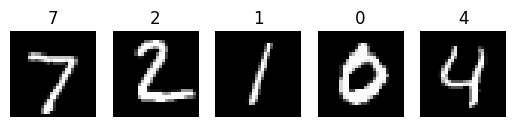

In [150]:
import matplotlib.pyplot as plt

for i in range(5):
    img, label = test_dataset_original[i]
    plt.subplot(1, 5, i+1)
    plt.imshow(img.squeeze(), cmap='gray')
    plt.title(str(label))
    plt.axis('off')
plt.show()

In [151]:
x, y = test_dataset_original[0]

In [152]:
sq_x = x.numpy().squeeze()

In [166]:
# 7. 이미지를 오른쪽으로 이동시킨 새로운 테스트셋 만들기
def shift_image_tensor(img_tensor, dx=10, dy=5):
    img_np = img_tensor.numpy().squeeze()
    shifted_np = shift(img_np, shift=[dy, dx], mode='nearest') # shift 함수가 numpy array를 입력으로 받음 
                                                               # shift 연산은 2차원 평면 상의 이동을 수행함 
                                                               # nearest: 이미지가 바깥으로 밀려나면서 빈 공간이 생김 -> 가장 가까운 픽셀 값으로 채움
    return torch.tensor(shifted_np).unsqueeze(0)  # unsqueeze 연산은 squeeze 연산의 반대 즉, axis=0 을 기준으로 축을 하나 더 생성 

shifted_imgs = []
shifted_labels = []

for img, label in test_dataset_original:
    shifted_img = shift_image_tensor(img)
    shifted_imgs.append(shifted_img)
    shifted_labels.append(label)

shifted_dataset = list(zip(shifted_imgs, shifted_labels))
shifted_loader = DataLoader(shifted_dataset, batch_size=BATCH_SIZE, shuffle=False) # 학습 데이터, 라벨 데이터 쌍의 iterable 객체를 인자로 받음 

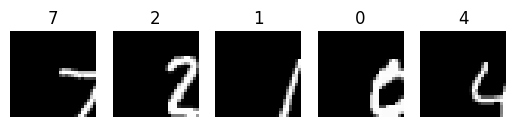

In [167]:
import matplotlib.pyplot as plt

for i in range(5):
    img, label = shifted_dataset[i]
    plt.subplot(1, 5, i+1)
    plt.imshow(img.squeeze(), cmap='gray')
    plt.title(str(label))
    plt.axis('off')
plt.show()

In [168]:
# 8. 이동된 이미지 정확도 평가
acc_shifted = evaluate(model, shifted_loader)
print(f"⚠️  오른쪽으로 이동한 이미지 정확도: {acc_shifted:.4f}")

⚠️  오른쪽으로 이동한 이미지 정확도: 0.0849


### 🧩 Quiz 2

1. DNN이 이미지 입력의 위치 변화에 민감하게 반응하는 이유는?

2. DNN은 2차원 이미지 데이터를 그대로 입력으로 받을 수 있다. 

3. DNN은 이미지 픽셀 하나하나의 절대적인 숫자에 집중해서 학습하는 경향이 있다. 

4. MNIST 테스트셋에서 모든 픽셀에 0.2를 더한 데이터 셋을 생성하고, 생성한 데이터 셋으로 성능 평가를 진행 하시오. 

1. DNN이 이미지 입력의 위치 변화에 민감하게 반응하는 이유는?
- 2차원 공간 정보를 무시하고 1차원으로 펼쳐서 처리하기 때문에
- 위치 정보가 손실되어, 같은 패턴이라도 다른 위치에 있으면 다르게 인식함

2. DNN은 2차원 이미지 데이터를 그대로 입력으로 받을 수 있다. 
- X 

3. DNN은 이미지 픽셀 하나하나의 절대적인 숫자에 집중해서 학습하는 경향이 있다. 
- O 

4. MNIST 테스트셋에서 모든 픽셀에 0.2를 더한 데이터 셋을 생성하고, 생성한 데이터 셋으로 성능 평가를 진행 하시오. 

In [183]:
x, y = test_dataset_original[0]

In [170]:
x.shape

torch.Size([1, 28, 28])

In [171]:
x.max(), x.min()

(tensor(1.), tensor(0.))

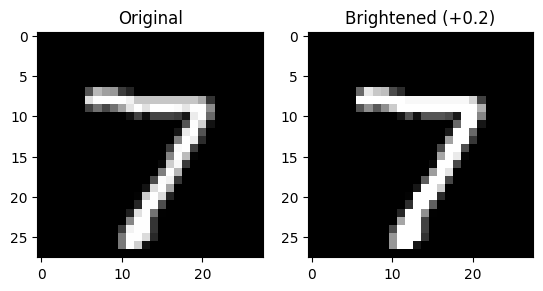

In [192]:
# 밝기 조절 함수 정의
def brighten_image(img_tensor, delta=0.2):
    return torch.clamp(img_tensor + delta, 0.0, 1.0)

def brighten_image2(img_tensor, delta=0.2):
    return torch.min(img_tensor + delta, torch.ones_like(img_tensor)) # shape, device 일치시켜야 브로드 캐스팅 연산 가능

# 새로운 이미지 리스트 만들기
bright_imgs = []
bright_labels = []

for img, label in test_dataset_original:
    bright_img = brighten_image(img, delta=0.2)
    bright_imgs.append(bright_img)
    bright_labels.append(label)

# 새로운 DataLoader 만들기
bright_dataset = list(zip(bright_imgs, bright_labels))
bright_loader = DataLoader(bright_dataset, batch_size=64, shuffle=False)

# 원본 이미지 vs 밝기 증가 이미지 비교
original_img, _ = test_dataset_original[0]
bright_img = brighten_image(original_img)

plt.subplot(1, 2, 1)
plt.imshow(original_img.squeeze(), cmap='gray')
plt.title("Original")

plt.subplot(1, 2, 2)
plt.imshow(bright_img.squeeze(), cmap='gray')
plt.title("Brightened (+0.2)")

plt.show()

In [193]:
acc_bright = evaluate(model, bright_loader)
print(f"🌕 밝아진 테스트셋 정확도: {acc_bright:.4f}")

🌕 밝아진 테스트셋 정확도: 0.5480


5. 변형된 데이터 셋의 평가 결과가 원본 데이터 셋의 평가 결과가 다른 이유가 무엇인가요?

- MNIST 데이터는 지금 0과 1사이로 정규화 되어 있음
- 모델이 학습한 분포와 전혀 다르기 때문에 활성화 함수의 동작이 이전과 다를 가능성이 큼
- 분류 경계도 벗어나는 경우가 많아질 가능성이 큼 

## <a id='three'>3️⃣ 시각처리 딥러닝의 시작</a><br>

<a href="#lecture_index">
    <span>⬆ 목차로</span>
</a>

## 인간의 시각처리 방식 

<img src="사진/human_visual.png" width=650 height=400 alt="human_visual"/>

참고: https://designcompass.org/2021/07/18/%EC%8B%9C%EA%B0%81-%EC%9D%B8%EC%A7%80-visual-perception/

```
1. 망막에 맺힌 상이 맺히면 빛을 전기적 신호로 변환 한다 
2. 오른쪽으로 들어온 시야 정보는 좌뇌로, 왼쪽으로 들어온 시야 정보는 우뇌로 전달된다 
3. LGN에서 빠른 반응이 필요한 정보(움직임, 명암)와 느린 반응(색상)이어도 괜찮은 정보를 나눔
4. v1은 기본적인 선, 방향 감지
5. v2는 곡선, 윤곽 감지
6. v3는 윤곽, 깊이 감지
7. v4는 색상, 형태 분석 
8. v5는 움직임 분석 
9. LOC는 최종 사물 인식 ('이것이 무엇인가?를 판단')
```

## LeNet-5 구조 이해하기 

> 인간의 시각 처리 과정도 이미지를 한 번에 이해하지 않고, 부분부분 확인하고, 계층적으로 처리를 한다는 것을 확인<br>
> 이런 인간의 시각 처리 과정이 가능한 방식을 처음 제안함 

참고: http://vision.stanford.edu/cs598_spring07/papers/Lecun98.pdf

<img src="사진/lenet5.png" width=900 height=400 alt="lenet5"/>

```
Input layer -> [C1] Convolution layer -> [S2] Subsampling layer(Average pooling) 
            -> [C3] Convolution layer -> [S4] Subsampling layer(Average pooling)
            -> [C5] Convolution layer -> [F6] Fully Connected Layer 
            -> [Output] Fully Connected Layer 
```

🚀 저수준 특징 -> 중간 수준 -> 고수준 특징 추출 후 '어떤 조합의 특징들이 어떤 클래스에 해당할까를 학습하는 과정'

🛠️ 
- @ -> 채널 수와 공간의 크기를 연결해서 표현하는 표기 방식
- 채널 -> 어떤 특정한 특징을 감지하는 이미지 ex) 3원색을 혼합하여 색을 표현하는 방식 RGB 

참고: https://cs.stanford.edu/people/karpathy/convnetjs/demo/cifar10.html

## LeNet-5 모델을 활용하여 MNIST 데이터 학습하기

In [197]:
img, label = next(iter(train_loader))

In [ ]:
img.shape # 미니 배치 64개로 구성되어 있는 1x32x32 이미지 데이터 (batch size, channel, Height, Width) 

torch.Size([64, 1, 32, 32])

In [201]:
import matplotlib.pyplot as plt

import torch
import torchvision
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import DataLoader
from torch.utils.data import random_split, ConcatDataset

# 1. MNIST 데이터셋 로딩 (LeNet은 32x32 이미지 사용)
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor()
])

# 1. 두 개의 dataset을 하나로 합치기
train_raw = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_raw  = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
full_dataset = ConcatDataset([train_raw, test_raw])  # 60,000 + 10,000 = 70,000

# 2. 비율 설정 (70%, 10%, 20%)
total_size = len(full_dataset)
train_size = int(0.7 * total_size)   # 49,000
valid_size = int(0.1 * total_size)   # 7,000
test_size  = total_size - train_size - valid_size  # 14,000

train_dataset, valid_dataset, test_dataset = random_split(full_dataset, [train_size, valid_size, test_size])

# 3. DataLoader로 만들기
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True) # 학습 데이터 셋만 섞는다 
valid_loader = DataLoader(valid_dataset, batch_size=64, shuffle=False) # 평가 기준을 동일하게 하기 위해서 (재현 가능하게 하기 위해서)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

# 특징 추출 부분 (Conv + Pooling)
feature_extractor = nn.Sequential(
    # [C1]
    nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5),   # 32x32 → 28x28
    nn.Tanh(), 
    # [S2]
    nn.AvgPool2d(kernel_size=2, stride=2),                      # 28x28 → 14x14
  
    # [C3]
    nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5),  # 14x14 → 10x10
    nn.Tanh(),
    # [S4]
    nn.AvgPool2d(kernel_size=2, stride=2),                       # 10x10 → 5x5
    
    # [C5]
    nn.Conv2d(in_channels=16, out_channels=120, kernel_size=5),  # 5x5 → 1x1 
    nn.Tanh()
)

# 분류기 부분 (Fully Connected)
classifier = nn.Sequential(
    nn.Linear(in_features=120, out_features=84),
    nn.Tanh(),
    nn.Linear(in_features=84, out_features=10)
)

# 전체 네트워크 동작 테스트
def forward(x):
    x = feature_extractor(x)                   # [B, 1, 32, 32] → [B, 120, 1, 1]
    x = torch.flatten(x, start_dim=1)          # [B, 120, 1, 1] → [B, 120]
    x = classifier(x)                          # [B, 400] → [B, 10]
    return x

In [202]:
# 4. 학습 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
feature_extractor.to(device)
classifier.to(device)

params = list(feature_extractor.parameters()) + list(classifier.parameters())
optimizer = torch.optim.Adam(params, lr=0.001)
criterion = nn.CrossEntropyLoss()

# 학습 로그 저장용 리스트
train_losses = []
train_accuracies = []
valid_losses = []
val_accuracies = []

# 5. 학습 & 검증 루프 
def train_valid_model(epoch=10):
    for ep in range(epoch):
        # ---- Train Step ----
        feature_extractor.train()
        classifier.train()

        train_total_loss = 0
        train_correct = 0
        train_total = 0

        for i, (imgs, labels) in enumerate(train_loader):
            imgs, labels = imgs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = forward(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            batch_size = labels.size(0)                    # batch size가 고정이더라도 마지막 batch size는 고정된 사이즈보다 작을 수 있기 때문에 학습 중에 batch size를 확인
            train_total_loss += loss.item() * batch_size   # loss.item()은 미니 배치의 평균 손실 값을 출력하기 때문에 batch_size를 곱해야 정확한 전체 loss의 평균을 구할 수 있음
            train_total += batch_size                      # 지금까지 학습한 데이터 개수 누적 
            _, predicted = torch.max(outputs.data, 1)
            train_correct += (predicted == labels).sum().item()

            if (i + 1) % 100 == 0:
                print(f"Epoch {ep+1}, Step {i+1}: Train Loss (batch): {loss.item():.4f}")
            
        # 학습 데이터 loss 계산 및 정확도 계산 
        avg_train_loss = train_total_loss / train_total
        train_acc = 100 * train_correct / train_total

        # loss, acc 누적 (그래프 그리기용)
        train_losses.append(avg_train_loss)
        train_accuracies.append(train_acc)
        
        # ----- Validation Phase -----
        feature_extractor.eval()
        classifier.eval()

        val_total_loss = 0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for val_imgs, val_labels in valid_loader:
                val_imgs, val_labels = val_imgs.to(device), val_labels.to(device)
                val_outputs = forward(val_imgs)
                val_loss = criterion(val_outputs, val_labels)

                val_batch_size = val_labels.size(0)
                val_total_loss += val_loss.item() * val_batch_size
                val_total += val_batch_size
                _, val_predicted = torch.max(val_outputs.data, 1)
                val_correct += (val_predicted == val_labels).sum().item()

        # 검증 데이터 loss 계산 및 정확도 계산 
        avg_val_loss = val_total_loss / val_total
        val_acc = 100 * val_correct / val_total

        valid_losses.append(avg_val_loss)
        val_accuracies.append(val_acc)

        print(f"[Epoch {ep+1}] Train Loss: {avg_train_loss:.4f}, Train Accuracy: {train_acc:.2f}%")
        print(f"[Epoch {ep+1}] Val   Loss: {avg_val_loss:.4f}, Val   Accuracy: {val_acc:.2f}%\n")


# 6. 테스트 함수
def test_model():
    feature_extractor.eval()
    classifier.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = forward(imgs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    print(f"Test Accuracy: {100 * correct / total:.2f}%")

In [204]:
# 학습 로그 시각화 함수
def plot_logs(train_losses, valid_losses, train_accuracies, val_accuracies):
    epochs = range(1, len(train_losses) + 1)

    plt.figure(figsize=(12, 5))

    # Loss 그래프
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, label='Train Loss', marker='o')
    plt.plot(epochs, valid_losses, label='Valid Loss', marker='o')
    plt.title('Loss over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.legend()

    # Accuracy 그래프
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accuracies, label='Train Accuracy', marker='o')
    plt.plot(epochs, val_accuracies, label='Validation Accuracy', marker='x')
    plt.title('Accuracy over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

In [38]:
train_valid_model(epoch=5)

Epoch 1, Step 100: Train Loss (batch): 0.4246
Epoch 1, Step 200: Train Loss (batch): 0.2111
Epoch 1, Step 300: Train Loss (batch): 0.2375
Epoch 1, Step 400: Train Loss (batch): 0.2111
Epoch 1, Step 500: Train Loss (batch): 0.1697
Epoch 1, Step 600: Train Loss (batch): 0.2837
Epoch 1, Step 700: Train Loss (batch): 0.0885
[Epoch 1] Train Loss: 0.3200, Train Accuracy: 90.69%
[Epoch 1] Val   Loss: 0.1427, Val   Accuracy: 95.70%

Epoch 2, Step 100: Train Loss (batch): 0.0847
Epoch 2, Step 200: Train Loss (batch): 0.0473
Epoch 2, Step 300: Train Loss (batch): 0.1363
Epoch 2, Step 400: Train Loss (batch): 0.1941
Epoch 2, Step 500: Train Loss (batch): 0.0486
Epoch 2, Step 600: Train Loss (batch): 0.1251
Epoch 2, Step 700: Train Loss (batch): 0.0648
[Epoch 2] Train Loss: 0.1070, Train Accuracy: 96.71%
[Epoch 2] Val   Loss: 0.1047, Val   Accuracy: 96.80%

Epoch 3, Step 100: Train Loss (batch): 0.0534
Epoch 3, Step 200: Train Loss (batch): 0.1310
Epoch 3, Step 300: Train Loss (batch): 0.0214
Epoc

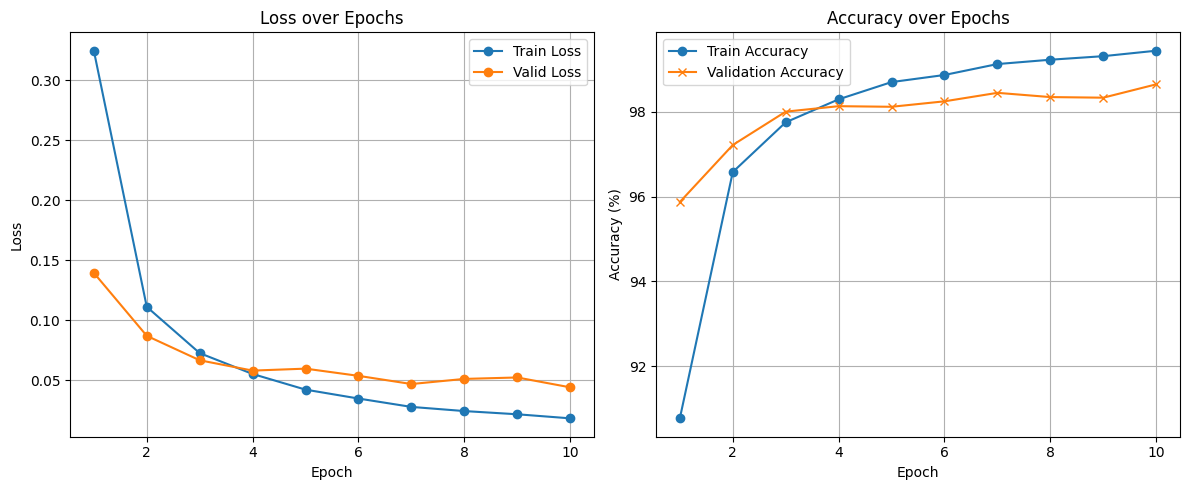

In [205]:
plot_logs(train_losses, valid_losses, train_accuracies, val_accuracies)

In [206]:
test_model()

Test Accuracy: 98.46%


### 🧩 Quiz 3

1. LeNet-5에서 C5 layer에서 2차원의 입력값을 1차원으로 축소한 이유는? 

2. C5 layer에서 이미 1차원으로 축소를 했지만 바로 output layer로 연결하지 않고 F6 layer를 추가한 이유는? 

3. nn.Module을 상속받아서 객체지향 방식으로 LeNet-5 모델을 구현하시오

1. LeNet-5에서 C5 layer에서 2차원의 입력값을 1차원으로 축소한 이유는? 
- 분류 문제를 풀기 위해서는 클래수 개수에 맞는 아웃풋이 필요하기 때문에 
- 공간 정보에서 의미 정보로 넘어가는 다리 역할을 하기 위해 
- 추출된 특징들을 기반으로 어떤 클래스인지 결정하기 위해 
- FC layer는 1D 입력만 처리할 수 있기 때문에 

2. C5 layer에서 이미 1차원으로 축소를 했지만 바로 output layer로 연결하지 않고 F6 layer를 추가한 이유는? 
- 고수준의 특징들(선, 곡선, 윤곽, 색상 등)을 조합하여 바로 클래스 예측을 하기에는 조합이 부족하기 때문에 더 다양한 조합으로 의미 있는 조합을 만들어 내기 위해 레이어를 추가 
- 비선형 조합을 통해 클래스 구분 경계를 더 정교하게 만들 수 있음 
- 분류기 파라미터 수가 늘어나면 더 많은 데이터가 필요하고, 데이터가 적으면 모델은 통계적으로 의미 없는 패턴을 학습하게 됨. 따라서 파라미터를 단계적으로 줄이는 과정을 추가함으로써 패턴을 의미 있게 만드는 작업이 필요

3. nn.Module을 상속받아서 객체지향 방식으로 LeNet-5 모델을 구현하시오

In [41]:
class LeNet5(nn.Module):
    def __init__(self):
        super(LeNet5, self).__init__()
        self.feature_extractor = nn.Sequential(
            nn.Conv2d(1, 6, kernel_size=5),     # 32x32 → 28x28
            nn.Tanh(),
            nn.AvgPool2d(2, stride=2),          # 28x28 → 14x14
            nn.Conv2d(6, 16, kernel_size=5),    # 14x14 → 10x10
            nn.Tanh(),
            nn.AvgPool2d(2, stride=2),          # 10x10 → 5x5
            nn.Conv2d(16, 120, kernel_size=5),  # 5x5 → 1x1
            nn.Tanh()
        )
        self.classifier = nn.Sequential(
            nn.Linear(120, 84),
            nn.Tanh(),
            nn.Linear(84, 10)
        )

    def forward(self, x):
        x = self.feature_extractor(x)           # [B, 1, 32, 32] → [B, 120, 1, 1]
        x = torch.flatten(x, start_dim=1)       # → [B, 120]
        x = self.classifier(x)                  # → [B, 10]
        return x

In [42]:
# 5. 학습 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = LeNet5().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

train_losses = []
train_accuracies = []
valid_losses = []
val_accuracies = []

# 6. 학습 & 검증 루프
def train_valid_model(epoch=10):
    for ep in range(epoch):
        # ---- Train Step ----
        model.train()
        train_total_loss = 0
        train_correct = 0
        train_total = 0

        for i, (imgs, labels) in enumerate(train_loader):
            imgs, labels = imgs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            batch_size = labels.size(0)
            train_total_loss += loss.item() * batch_size
            train_total += batch_size
            _, predicted = torch.max(outputs.data, 1)
            train_correct += (predicted == labels).sum().item()

            if (i + 1) % 100 == 0:
                print(f"Epoch {ep+1}, Step {i+1}: Train Loss (batch): {loss.item():.4f}")

        avg_train_loss = train_total_loss / train_total
        train_acc = 100 * train_correct / train_total
        train_losses.append(avg_train_loss)
        train_accuracies.append(train_acc)

        # ---- Validation Step ----
        model.eval()
        val_total_loss = 0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for val_imgs, val_labels in valid_loader:
                val_imgs, val_labels = val_imgs.to(device), val_labels.to(device)
                val_outputs = model(val_imgs)
                val_loss = criterion(val_outputs, val_labels)

                val_batch_size = val_labels.size(0)
                val_total_loss += val_loss.item() * val_batch_size
                val_total += val_batch_size
                _, val_predicted = torch.max(val_outputs.data, 1)
                val_correct += (val_predicted == val_labels).sum().item()

        avg_val_loss = val_total_loss / val_total
        val_acc = 100 * val_correct / val_total
        valid_losses.append(avg_val_loss)
        val_accuracies.append(val_acc)

        print(f"[Epoch {ep+1}] Train Loss: {avg_train_loss:.4f}, Train Accuracy: {train_acc:.2f}%")
        print(f"[Epoch {ep+1}] Val   Loss: {avg_val_loss:.4f}, Val   Accuracy: {val_acc:.2f}%\n")

# 7. 테스트 함수
def test_model():
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    print(f"Test Accuracy: {100 * correct / total:.2f}%")

In [43]:
train_valid_model(3)

Epoch 1, Step 100: Train Loss (batch): 0.3299
Epoch 1, Step 200: Train Loss (batch): 0.5369
Epoch 1, Step 300: Train Loss (batch): 0.2583
Epoch 1, Step 400: Train Loss (batch): 0.2447
Epoch 1, Step 500: Train Loss (batch): 0.1741
Epoch 1, Step 600: Train Loss (batch): 0.1702
Epoch 1, Step 700: Train Loss (batch): 0.0779
[Epoch 1] Train Loss: 0.3131, Train Accuracy: 90.94%
[Epoch 1] Val   Loss: 0.1279, Val   Accuracy: 96.09%

Epoch 2, Step 100: Train Loss (batch): 0.1029
Epoch 2, Step 200: Train Loss (batch): 0.1392
Epoch 2, Step 300: Train Loss (batch): 0.1027
Epoch 2, Step 400: Train Loss (batch): 0.0930
Epoch 2, Step 500: Train Loss (batch): 0.1558
Epoch 2, Step 600: Train Loss (batch): 0.0483
Epoch 2, Step 700: Train Loss (batch): 0.1210
[Epoch 2] Train Loss: 0.0985, Train Accuracy: 96.98%
[Epoch 2] Val   Loss: 0.0889, Val   Accuracy: 97.13%

Epoch 3, Step 100: Train Loss (batch): 0.0587
Epoch 3, Step 200: Train Loss (batch): 0.0157
Epoch 3, Step 300: Train Loss (batch): 0.1243
Epoc

## <a id='four'>4️⃣ 합성곱 신경망 (CNN)</a><br>

<a href="#lecture_index">
    <span>⬆ 목차로</span>
</a>

## CNN 구조 개념

<img src="사진/cnn.png" width=900 height=400 alt="cnn"/>

### Convolution Layer
> 지역적인 특징(예: 선, 모서리)을 추출하는 역할. 커널(kernel)이라는 작은 필터를 통해 입력 이미지와 합성곱 연산을 수행함.

### Activation Function (ReLU 등..)
> 비선형성을 추가하여 모델이 더 복잡한 패턴을 학습할 수 있게 함. 주로 ReLU가 사용됨.

### Pooling Layer
> 특징 맵의 크기를 줄이고, 계산량 감소 및 과적합 완화에 도움을 줌. 주로 MaxPooling이 사용됨.

### Flatten & Fully Connected Layer
> 추출된 특징을 일렬로 펴서 최종 분류기로 전달하는 역할을 함.

## CNN 모델을 활용한 FashionMNIST 데이터 학습

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms  # torchvision: 이미지 및 비디오 데이터셋, 모델, 변환기 등을 포함하는 패키지
import torchvision.datasets as datasets
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 데이터셋 로드
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_dataset = datasets.FashionMNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = datasets.FashionMNIST(root='./data', train=False, transform=transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [208]:
data = iter(train_loader)

In [209]:
image, label = next(data)

In [210]:
image.shape # Batch size / channel / 28x28 

torch.Size([64, 1, 28, 28])

In [ ]:
# CNN 모델 정의
class FashionMNIST_CNN(nn.Module):
    def __init__(self):
        super(FashionMNIST_CNN, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 28x28 → 14x14
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)   # 14x14 → 7x7
        )
        self.fc_layers = nn.Sequential(
            nn.Flatten(),           
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )
    
    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

In [211]:
model = FashionMNIST_CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [212]:
# 모델 학습 함수
def train_model(model, train_loader, criterion, optimizer, epochs=5):
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
        
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {total_loss/len(train_loader):.4f}")

# 모델 평가 함수
def evaluate_model(model, test_loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    print(f"Test Accuracy: {100 * correct / total:.2f}%")

In [26]:
train_model(model, train_loader, criterion, optimizer, epochs=10)

Epoch [1/10], Loss: 0.4397
Epoch [2/10], Loss: 0.2783
Epoch [3/10], Loss: 0.2297
Epoch [4/10], Loss: 0.1974
Epoch [5/10], Loss: 0.1721
Epoch [6/10], Loss: 0.1488
Epoch [7/10], Loss: 0.1291
Epoch [8/10], Loss: 0.1114
Epoch [9/10], Loss: 0.0939
Epoch [10/10], Loss: 0.0814


In [27]:
evaluate_model(model, test_loader)

Test Accuracy: 91.96%


In [219]:
target_labels

{0: 'T-shirt/top',
 1: 'Trouser',
 2: 'Pullover',
 3: 'Dress',
 4: 'Coat',
 5: 'Sandal',
 6: 'Shirt',
 7: 'Sneaker',
 8: 'Bag',
 9: 'Ankle boot'}

In [220]:
target_labels = {v: k for k, v in train_dataset.class_to_idx.items()}

def visualize_predictions(model, test_loader):
    model.eval()
    images, labels = next(iter(test_loader))
    images, labels = images[:20].to(device), labels[:20].to(device)
    
    with torch.no_grad(): 
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
    
    images = images.cpu().numpy() 
    
    fig, axes = plt.subplots(4, 5, figsize=(10, 5))  # axes: 2x5의 subplot을 가지는 figure 생성
    for i, ax in enumerate(axes.flat): # axes.flat: 1차원으로 평평하게 만들어주는 함수 -> 10개의 subplot을 순차적으로 접근 가능
        img = images[i].squeeze()
        ax.imshow(img, cmap='gray')
        ax.set_title(f"True: {target_labels[labels[i].item()]}\nPred: {target_labels[predicted[i].item()]}")
        ax.axis('off')
    plt.tight_layout()
    plt.show()

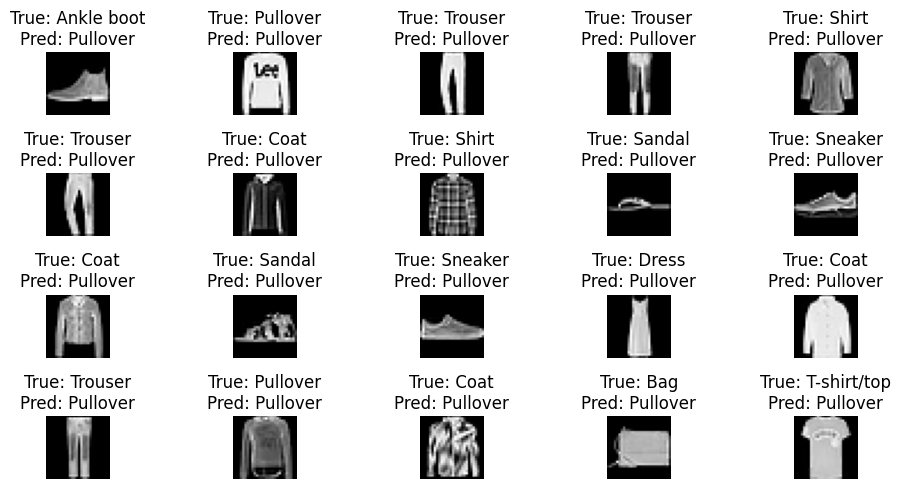

In [221]:
visualize_predictions(model, test_loader)

### Pooling을 사용하지 않으면 어떤 일이 생길까?

> 출력 feature map의 크기를 줄일 수 없게 되고, 계산량이 커지며, 과적합 가능성도 증가

```
• 계산량 증가: feature map의 크기가 유지되므로, 다음 layer의 연산량이 많아짐
• 메모리 사용량 증가: GPU 메모리도 많이 차지
• 과적합 가능성 증가: 불필요하게 세부 정보까지 학습해버릴 수 있음
• 위치 불변성 저하: Pooling은 특징의 위치 변화(예: 약간의 이동)에 강인한 특성을 만들어줌
```

### Conv layer를 두 개 이상 쌓는 이유는?

> 계층적으로 복잡한 특징을 학습하기 위해

```
• 1번째 Conv Layer: 단순한 특징 (선, 점, 모서리 등)
• 2번째 Conv Layer: 곡선, 패턴 등 복합적인 특징
• 3번째 이후: 추상적인 개념, 물체의 윤곽 등

즉, 깊게 쌓을수록 더 고차원의 의미를 학습할 수 있음
(= 계층적 특징 추출)
```

### 커널 사이즈를 바꾸면 어떤 변화가 있을까?

> 커널 사이즈는 특징을 바라보는 ‘시야’(receptive field)의 크기에 해당

```
• 작은 커널 (예: 3x3)
→ 세밀한 특징 감지 (디테일, 가장자리, 텍스처 등)
• 큰 커널 (예: 5x5, 7x7)
→ 넓은 영역의 정보 감지 (형태, 덩어리 구조 등)

하지만 커널이 너무 크면 파라미터 수가 많아지고, 과적합 위험도 있음
```

### 🧩 Quiz 4

1. CNN에서 파라미터 수가 가장 많은 레이어는 어떤 종류인가요?

2. MaxPooling의 주요 목적은?

3. Conv2D(1, 16, kernel_size=3, padding=1)의 파라미터 수는?

4. Flatten 레이어가 필요한 이유는?

5. 다음 중 CNN의 장점이 아닌 것은?
   - a) 지역적 특징 추출
   - b) 파라미터 공유
   - c) 시계열 데이터 처리에 특화됨
   - d) 계층적 특징 구성

1. CNN에서 파라미터 수가 가장 많은 레이어는 어떤 종류인가요?
- Fully Connected Layer (FC)
- Conv는 파라미터 수가 비교적 작고 반복 사용됨. FC는 입력 크기 × 출력 크기만큼 파라미터 존재!

2. MaxPooling의 주요 목적은?
- 특징 맵의 크기 축소 + 위치 불변성 확보

3. Conv2D(1, 16, kernel_size=3, padding=1)의 파라미터 수는?
- 1(in) × 16(out) × 3 × 3 = 144
- (바이어스 16개 포함 시 총 160)

4. Flatten 레이어가 필요한 이유는?
- Conv 레이어의 출력(다차원)을 FC 레이어 입력(1차원)으로 바꾸기 위해

5. 다음 중 CNN의 장점이 아닌 것은?
   - a) 지역적 특징 추출
   - b) 파라미터 공유
   - c) 시계열 데이터 처리에 특화됨
   - d) 계층적 특징 구성

- C

## <a id='five'>5️⃣ CNN을 이루는 구성 요소들</a><br>

<a href="#lecture_index">
    <span>⬆ 목차로</span>
</a>

### 커널(Kernel)
> 이미지 위에서 작은 창(행렬)을 가지고 숫자를 곱하고 더하는 연산을 하는 도구 <br>
> 보통 크기는 3x3, 5x5처럼 작고 정사각형 형태를 가짐 <br>
> 커널은 채널 수와 무관하게, 공간적(2D) 특징을 추출하는 작은 가중치 행렬

#### 🐝 쉬운 설명
> 커널은 확대경에 비유 할 수 있음 <br>
> 이미지를 확대경으로 좌측 위에서부터 우측 아래로가면서 특정한 패턴을 찾아내는 도구라고 생각하면 됨

<img src="사진/kernel.png" width=900 height=400 alt="kernel"/>

출처: https://medium.com/@abhishekjainindore24/all-about-convolutions-kernels-features-in-cnn-c656616390a1

In [222]:
import cv2 # pip install opencv-python  -> 이미지 처리를 쉽게 할 수 있는 라이브러리 ㄴ
 
import torch
import torch.nn as nn
import torch.nn.functional as F

In [227]:
image = cv2.imread("사진/animal.png")

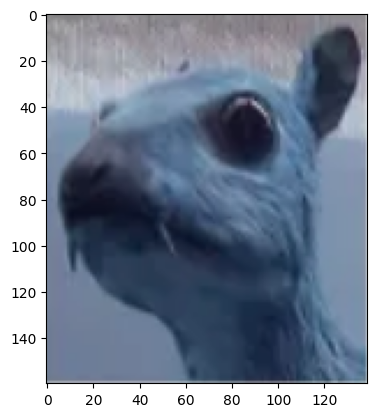

In [228]:
plt.imshow(image)

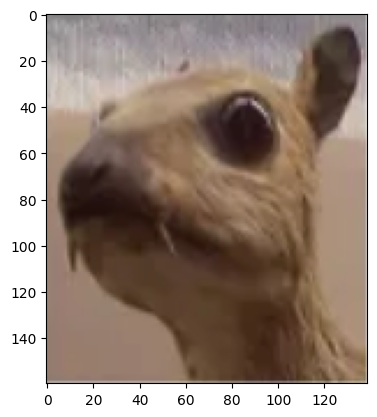

In [226]:
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # OpenCV는 기본적으로 BGR로 이미지를 불러오므로 RGB로 변환
plt.imshow(image_rgb)

In [229]:
image_rgb.shape

(160, 139, 3)

In [231]:
# numpy → torch tensor로 변환 + (H, W, C) → (C, H, W)
img_tensor = torch.from_numpy(image_rgb).float() / 255.0  # [0, 1]로 정규화 
img_tensor = img_tensor.permute(2, 0, 1).unsqueeze(0)    # (1, 3, 160, 139) -> Conv2d가 4D 텐서를 입력으로 받기 때문에 

edge_kernel = torch.tensor([[[[-1., -1., -1.],
                              [-1., 8., -1.],
                              [-1., -1., -1.]]]])
edge_kernel = edge_kernel.expand(3, 1, 3, 3) # rgb 채널에 동일하게 적용하기 위해 / 커널 3개가 (1, 3, 3) 형태

# padding이 1인 이유는 출력 크기를 유지하기 위해서 / bias가 False인 것은 추가적인 상수 값을 더하지 않겠다는 의미 
# group=3은 R/G/B 각각 독립적으로 연산을 하겠다는 의미 
# Conv2d는 (batch, channel, H, W) 형태를 입력으로 받음 
conv = nn.Conv2d(in_channels=3, out_channels=3, kernel_size=3, padding=1, groups=3, bias=False)  # group=1 
conv.weight.data = edge_kernel
conv.weight.requires_grad = False 

In [ ]:
edge_tensor = conv(img_tensor) # edge detection (convolution 연산)

In [234]:
edge_img = edge_tensor.squeeze(0).permute(1, 2, 0).detach().numpy()  # (H, W, C)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5215688..4.556863].


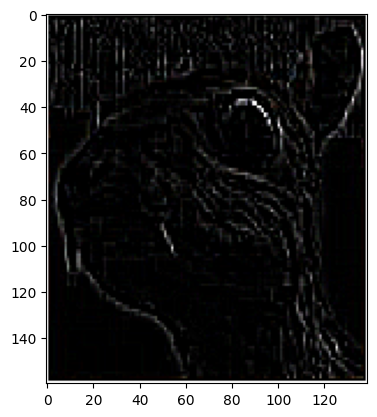

In [235]:
plt.imshow(edge_img)

In [ ]:
batch channel height width 

### 필터(Filter)
> 여러 커널들의 묶음 <br>
> 여러 개의 커널(입력 채널 수만큼)을 묶어 하나의 출력 채널을 만드는 단위

In [ ]:
conv = nn.Conv2d(in_channels=3, out_channels=2, kernel_size=3, groups=1)

In [238]:
conv.weight.shape # (out_channels, in_channels, kernel_h, kernel_w)

# 출력 채널이 2 -> 필터 2개 
# 각 필터는 입력 채널이 3개니까 각 필터는 3개의 (3x3) 커널을 가지고 있음 

torch.Size([2, 3, 3, 3])

In [239]:
conv = nn.Conv2d(in_channels=3, out_channels=3, kernel_size=3, groups=3)

In [240]:
conv.weight.shape
# 출력 채널이 3 -> 필터 3개 
# 각 필터는 입력 채널이 1개니까 각 필터는 1개의 (3x3) 커널을 가지고 있음 

torch.Size([3, 1, 3, 3])

In [245]:
conv = nn.Conv2d(in_channels=4, out_channels=6, kernel_size=3, groups=2)

In [ ]:
conv.weight.shape # 4개 필터

torch.Size([6, 2, 3, 3])

#### 🐝 비유로 설명
- 🎨 일반 Conv (groups=1): 모든 색(R, G, B…)을 섞어 새 색을 만들어냄
- 🔍 Depthwise Conv (groups=in_channels): 각 색을 따로 보고 각각 결과 냄
- ⚙️ Grouped Conv (groups=2): 두 색씩 묶어서 따로 처리함

### 합성곱 연산 (Convolution)
> 커널이 입력 이미지 위를 슬라이딩하며 영역마다 곱셈+합산 연산을 수행 <br>
> 합성곱 연산을 통해 특징을 뽑아낸다 

🛠️ 합성곱 연산은 수학적으로 커널을 180도 회전시킨 뒤, 데이터(입력)에 슬라이딩하면서 대응하는 위치끼리 곱하고 더하는 연산 <br>
참고: https://pinkwink.kr/156

#### ⭐️ 합성곱 연산의 핵심: "커널의 모양이 입력에 얼마나 ‘똑같이’ 들어맞는지 확인" 

#### 수학적 관점의 합성곱 연산

In [260]:
data = [1, 2, 3, 4, 5]
filter = [2, 4, 8]  # 커널이 갖는 의미 -> 10: 작은 중요도 / 20: 중간 중요도 / 30: 큰 중요도  | 그대로 연산을 하면 그냥 두 값이 동시에 커져서 유사도를 구하는 것이 아니라 같이 커지기만 함
flipped_filter = filter[::-1] # 패턴을 찾기 위해 커널을 뒤집음 | 역방향으로 연산을 하면 진짜 유사도를 구할 수 있고 패턴을 찾을 수 있음

In [261]:
output = []
for i in range(len(data) - len(filter) + 1):
    window = data[i:i+len(filter)]
    result = sum([window[j] * filter[j] for j in range(len(filter))])
    output.append(result)

In [ ]:
output # 14 14

[34, 48, 62]

In [264]:
output = []
for i in range(len(data) - len(flipped_filter) + 1):
    window = data[i:i+len(flipped_filter)]
    result = sum([window[j] * flipped_filter[j] for j in range(len(flipped_filter))])
    output.append(result)

In [ ]:
output # 14 14

[22, 36, 50]

<img src="사진/conv.png" width=600 height=300 alt="conv"/>

In [128]:
45*0 + 12*-1 + 5*0 + 22*-1 + 10*5 + 35*-1 + 88*0 + 26*-1 + 51*0

-45

참고: https://umbum.tistory.com/223

In [272]:
image = cv2.imread("사진/animal.png")
image = cv2.resize(image, (256, 256))
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

In [273]:
image_rgb.shape

(256, 256, 3)

In [274]:
image_tensor = torch.from_numpy(image_rgb).float() / 255.0        # (H, W, C)
image_tensor = image_tensor.permute(2, 0, 1).unsqueeze(0)         # (1, 3, H, W)

In [278]:
# 연산을 위해서 입력 채널과 in_channels가 같아야 함 
conv = nn.Conv2d(in_channels=3, out_channels=1, kernel_size=3, padding=1, bias=False)

In [279]:
conv.weight.data # 랜덤으로 초기화 되어 있음 

tensor([[[[-0.1899,  0.1415,  0.1633],
          [-0.0112, -0.0320, -0.0100],
          [ 0.0008, -0.1084, -0.1115]],

         [[ 0.1770, -0.1288,  0.1334],
          [-0.0009, -0.1681,  0.1555],
          [-0.0735, -0.1692,  0.1167]],

         [[ 0.1216, -0.0825, -0.1360],
          [ 0.1239,  0.1801, -0.0648],
          [-0.0314,  0.0045,  0.1589]]]])

In [280]:
output = conv(image_tensor)

In [282]:
image_tensor.shape

torch.Size([1, 3, 256, 256])

In [281]:
output.shape # batch size, channel, H, W

torch.Size([1, 1, 256, 256])

#### 💡 합성곱 연산은 커널을 뒤집어서 연산을 하는데 왜 torch.Conv2d 연산에서는 커널을 뒤집어서 하지 않는가? 

> CNN에서는 커널이 고정되어 있지 않고 학습하기 때문에 처음에 초기화된 값을 뒤집어도 나중에 바뀔거기 때문에 의미 없음!

### 수용 영역 (Receptive Field)
> 특정 뉴런(출력값)이 입력 이미지에서 영향을 받는 실제 범위 <br>
> 한 뉴런이 보는 전체 장면의 범위 <br>

<img src="사진/receptive_field1.png" width=700 height=400 alt="receptive_field1"/>

출처: https://www.sciencedirect.com/topics/engineering/receptive-field-size

Output Layer-1의 파란색 영역은 입력 이미지의 3x3영역을 보고 나온 결과 이기 때문에 convolution layer 1의 receptive field는 3x3  <br> 
Output Layer-2의 초록색 영역은 입력 이미지의 5x5영역을 보고 나온 결과 이기 때문에 convolution layer 2의 receptive field는 5x5

<img src="사진/receptive_field2.png" width=700 height=400 alt="receptive_field2"/>

출처: https://jaylala.tistory.com/entry/%EA%B0%9C%EB%85%90-%EC%A0%95%EB%A6%AC-CNN%EC%97%90%EC%84%9C-%EC%88%98%EC%9A%A9%EC%98%81%EC%97%AD%EC%9D%B4%EB%9E%80-Receptive-field%EB%9E%80

### 스트라이드(Stride)
> 커널이 한 번에 얼마나 이동할지를 나타냄 (기본값: 1칸) <br>
> 커널이 클 수록 빠르게 훑기 때문에 출력 크기는 작아지고 정보는 덜 세밀하게 봄

참고: https://umbum.tistory.com/223

In [283]:
image = cv2.imread("사진/animal.png")
image = cv2.resize(image, (256, 256))
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

image_tensor = torch.from_numpy(image_rgb).float() / 255.0        
image_tensor = image_tensor.permute(2, 0, 1).unsqueeze(0)    

conv = nn.Conv2d(in_channels=3, out_channels=1, kernel_size=3,
                 stride=2, padding=1, bias=False)

In [284]:
conv(image_tensor).shape

torch.Size([1, 1, 128, 128])

### 출력 크기 계산

<img src="사진/output_shape.png" width=750 height=300 alt="output_shape"/>

In [168]:
OH = (256 + 2*1 - 3) / 2 + 1
OW = (256 + 2*1 - 3) / 2 + 1

In [170]:
OH, OW  # nn.Conv2d는 출력 크기를 소수점 없이 내림 처리함

(128.5, 128.5)

### 패딩(Padding)
> 입력의 가장자리에 0을 추가해, 출력 크기 조절

In [175]:
image = cv2.imread("사진/animal.png")
image = cv2.resize(image, (256, 256))
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

image_tensor = torch.from_numpy(image_rgb).float() / 255.0        
image_tensor = image_tensor.permute(2, 0, 1).unsqueeze(0)    

conv = nn.Conv2d(in_channels=3, out_channels=1, kernel_size=3,
                 stride=2, padding=2, bias=False)

In [176]:
conv(image_tensor).shape

torch.Size([1, 1, 129, 129])

In [177]:
OH = (256 + 2*2 - 3) / 2 + 1
OW = (256 + 2*2 - 3) / 2 + 1

In [178]:
OH, OW

(129.5, 129.5)

In [290]:
# padding same은 kernel 사이즈에 따라서 자동으로 padding 값을 지정해줌
# padding same은 stride가 1일 때만 사용 가능
conv1 = nn.Conv2d(in_channels=3, out_channels=1, kernel_size=3,
                 stride=1, padding=1, bias=False)  

conv2 = nn.Conv2d(in_channels=3, out_channels=1, kernel_size=3,
                 stride=1, padding='same', bias=False)  

conv3 = nn.Conv2d(in_channels=3, out_channels=1, kernel_size=5,
                 stride=1, padding='same', bias=False)  

conv4 = nn.Conv2d(in_channels=3, out_channels=1, kernel_size=5,
                 stride=1, padding=2, bias=False)  

In [291]:
conv1(image_tensor).shape

torch.Size([1, 1, 256, 256])

In [287]:
conv2(image_tensor).shape

torch.Size([1, 1, 256, 256])

In [288]:
conv3(image_tensor).shape

torch.Size([1, 1, 256, 256])

In [289]:
conv4(image_tensor).shape

torch.Size([1, 1, 256, 256])

### 피처맵(Feature Map)
> 합성곱 연산으로 출력하는 결과 <br>
> 이미지에서 특정 특징(엣지, 무늬 등)이 활성화된 지도 <br>
> feature map은 의미/패턴 정보를 담고 있음

참고: https://cs.stanford.edu/people/karpathy/convnetjs/demo/cifar10.html

<img src="사진/featuremap.png" width=500 height=650 alt="featuremap"/>

Feature map shape: torch.Size([1, 8, 256, 256])


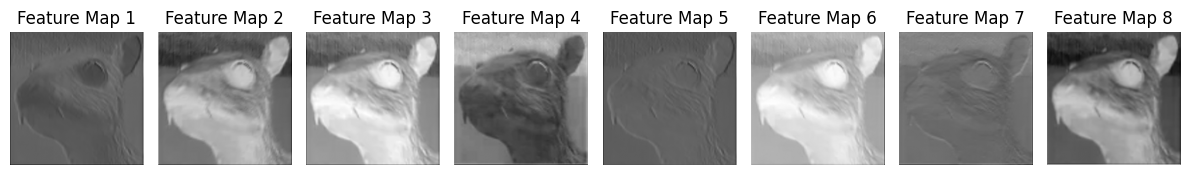

In [292]:
image = cv2.imread("사진/animal.png")
image = cv2.resize(image, (256, 256))
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

image_tensor = torch.from_numpy(image_rgb).float() / 255.0       # (H, W, C)
image_tensor = image_tensor.permute(2, 0, 1).unsqueeze(0)        # (1, 3, H, W)

conv = nn.Conv2d(in_channels=3, out_channels=8, kernel_size=3, padding=1, bias=False)

output = conv(image_tensor)  # shape: (1, 8, 256, 256)

print("Feature map shape:", output.shape)

# 5. Feature map 시각화
plt.figure(figsize=(12, 6))
for i in range(8):
    feature_map = output[0, i].detach().numpy() # output 텐서가 계산 그래프에 연결되어 있어서 바로 numpy() 메서드를 사용할 수 없음
    plt.subplot(1, 8, i+1)
    plt.imshow(feature_map, cmap='gray')
    plt.title(f"Feature Map {i+1}")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [193]:
output[0, 0].detach().cpu().numpy() # 정석은 cpu 연산으로도 옮겨야 함 (numpy array는 gpu 연산이 안되기 때문에)

array([[ 0.1870472 ,  0.16492692,  0.16429089, ...,  0.19305818,
         0.21929653,  0.1193633 ],
       [ 0.10982077, -0.00326941, -0.00292645, ...,  0.0060874 ,
         0.01891126, -0.0268095 ],
       [ 0.10642427, -0.0056069 , -0.00560605, ...,  0.00481238,
         0.0167361 , -0.02903448],
       ...,
       [ 0.11881118, -0.0174702 , -0.01792262, ..., -0.03044224,
        -0.01101857, -0.05595116],
       [ 0.1473113 ,  0.01224026,  0.01280238, ..., -0.00291912,
         0.00945177, -0.04426737],
       [ 0.22274815,  0.1003513 ,  0.10065766, ...,  0.08869116,
         0.10729963,  0.14387819]], dtype=float32)

### 채널(Channel)
> 이미지나 텐서에서 동시에 존재하는 여러 종류의 정보 층(layer)을 의미 <br>

- 예시) 이미지의 색상 정보 층 (보통 RGB: 3채널). 흑백 이미지는 1채널.

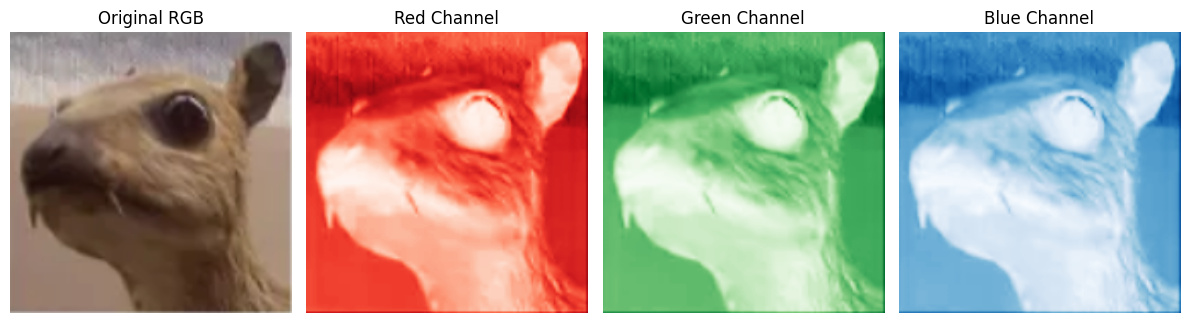

In [293]:
image = cv2.imread("사진/animal.png")
image = cv2.resize(image, (256, 256))
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

image_tensor = torch.from_numpy(image_rgb).float() / 255.0     # (H, W, C)
image_tensor = image_tensor.permute(2, 0, 1)                   # (C, H, W)

# 3. 채널 분리
R = image_tensor[0].numpy()
G = image_tensor[1].numpy()
B = image_tensor[2].numpy()

# 4. 시각화
plt.figure(figsize=(12, 4))
plt.subplot(1, 4, 1)
plt.imshow(image_rgb)
plt.title("Original RGB")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(R, cmap="Reds")
plt.title("Red Channel")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(G, cmap="Greens")
plt.title("Green Channel")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(B, cmap="Blues")
plt.title("Blue Channel")
plt.axis("off")

plt.tight_layout()
plt.show()

### 풀링(Pooling)
> 피처맵의 크기를 줄이고, 주요 정보만 유지하는 연산 <br>

🎉 효과 
- 연산량 감소 
- 물체가 이동해도 잘 인식될 수 있게 유도 (translation invariance)

### 풀링 종류 

1. Max Pooling 
2. Average Pooling 
3. Min Pooling
4. Global Average Pooling
-> 전체 영역에서 평균을 내는 방법 

<img src="사진/pooling.png" width=750 height=500 alt="pooling"/>

<img src="사진/gap.png" width=750 height=500 alt="gap"/>

In [ ]:
nn.AVG

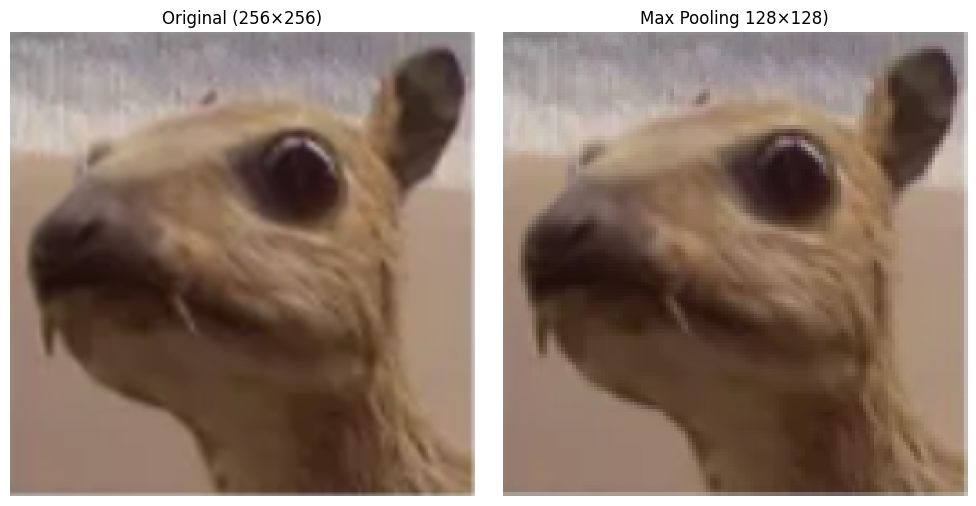

In [ ]:
image = cv2.imread("사진/animal.png")
image = cv2.resize(image, (256, 256))
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# 2. Tensor 변환
image_tensor = torch.from_numpy(image_rgb).float() / 255.0
image_tensor = image_tensor.permute(2, 0, 1).unsqueeze(0)  # (1, 3, 256, 256)

# 3. MaxPooling layer
pool = nn.MaxPool2d(kernel_size=2, stride=2)  # 2x2 영역에서 최대값, 크기 절반으로 줄임
# pool = nn.AvgPool2d(kernel_size=2, stride=2)# 2x2 영역에서 최대값, 크기 절반으로 줄임

# 4. 풀링 적용
pooled = pool(image_tensor)  # shape: (1, 3, 128, 128)

# 5. 시각화
pooled_image = pooled.squeeze(0).permute(1, 2, 0).detach().numpy()

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title("Original (256×256)")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(pooled_image)
plt.title("Max Pooling 128×128)")
plt.axis('off')

plt.tight_layout()
plt.show()

종류 | 특징/장점 | 사용 상황 
---|---|---
Max Pooling | 엣지, 텍스처 등 강한 특징 보존 | 강한 신호 중심 특징 추출 시 
Average Pooling | 전체 정보 반영, 노이즈 제거 | 노이즈가 많은 데이터, 정보를 평균화할 때 
Min Pooling | 가장 낮은 값 강조, 자주 사용 안함  | 음영 영역 강조 등 특수한 상황  
Global Avg Pooling | Flatten + FC layer 대체 가능, 경량화 | 분류기 출력 직전, 경량 모델에서 사용 
Global Max Pooling | 가장 강한 특징만 남김 | 텍스트, 오디오 등 강한 신호 존재 시 

### 🧩 Quiz 5

1. 커널이 3x3이고, 입력 채널이 1, 출력 채널이 10이라면 파라미터 수는?
- a) 9
- b) 90
- c) 30
- d) 10  

2. MaxPooling의 주요 효과는?
- a) 채널 수 증가
- b) 커널 크기 확장
- c) 계산량 감소 및 위치 불변성
- d) 커널 이동 속도 증가

3. 스트라이드가 커지면 출력 feature map은?
- a) 커진다
- b) 작아진다

4. 합성곱 연산은 어떤 연산을 반복하는가?
- a) 덧셈
- b) 평균
- c) 곱셈 후 합산
- d) 최대값 선택

5. CNN에서 파라미터 공유의 의미는?
- a) 모든 뉴런이 같은 출력을 가진다
- b) 하나의 커널이 전체 이미지에 사용된다

6. Conv2D 연산에서 입력 텐서와 커널 사이에 맞아야 하는 조건은?

- a) 입력 텐서의 너비는 커널의 높이보다 커야 한다
- b) 커널의 in_channels 수는 입력 텐서의 채널 수와 같아야 한다
- c) 출력 채널 수는 항상 1이다
- d) padding은 반드시 1이어야 한다

7. 입력 텐서의 shape이 (1, 3, 128, 128)일 때,
nn.Conv2d(in_channels=3, out_channels=8, kernel_size=3, padding=2)
을 통과한 출력 텐서의 shape은?

- a) (1, 3, 130, 130)
- b) (1, 3, 128, 128)
- c) (1, 8, 128, 128)
- d) (1, 8, 130, 130)

8. 아래와 같은 CNN의 구조에서 마지막 layer의 출력 뉴런 하나의 receptive field는 어떻게 되는가? 

```
Conv1: kernel=3x3, stride=1, padding=0
Conv2: kernel=5x5, stride=1, padding=0
Conv3: kernel=3x3, stride=1, padding=0
```

1. 커널이 3x3이고, 입력 채널이 1, 출력 채널이 10이라면 파라미터 수는?
- a) 9
- b) 90
- c) 30
- d) 10  

✅ **정답: b) 90** → 3x3=9 × 10개 필터 = 90

2. MaxPooling의 주요 효과는?
- a) 채널 수 증가
- b) 커널 크기 확장
- c) 계산량 감소 및 위치 불변성
- d) 커널 이동 속도 증가

✅ **정답: c)**

3. 스트라이드가 커지면 출력 feature map은?
- a) 커진다
- b) 작아진다

✅ **정답: b)**

4. 합성곱 연산은 어떤 연산을 반복하는가?
- a) 덧셈
- b) 평균
- c) 곱셈 후 합산
- d) 최대값 선택

✅ **정답: c)**

5. CNN에서 파라미터 공유의 의미는?
- a) 모든 뉴런이 같은 출력을 가진다
- b) 하나의 커널이 전체 이미지에 사용된다

✅ **정답: b)**

6. Conv2D 연산에서 입력 텐서와 커널 사이에 맞아야 하는 조건은?

- a) 입력 텐서의 너비는 커널의 높이보다 커야 한다
- b) 커널의 in_channels 수는 입력 텐서의 채널 수와 같아야 한다
- c) 출력 채널 수는 항상 1이다
- d) padding은 반드시 1이어야 한다

✅ **정답: b)**


7. 입력 텐서의 shape이 (1, 3, 128, 128)일 때,
nn.Conv2d(in_channels=3, out_channels=8, kernel_size=3, padding=2)
을 통과한 출력 텐서의 shape은?

- a) (1, 3, 130, 130)
- b) (1, 3, 128, 128)
- c) (1, 8, 128, 128)
- d) (1, 8, 130, 130)

✅ **정답: d)**

8. 아래와 같은 CNN의 구조에서 마지막 layer의 출력 뉴런 하나의 receptive field는 어떻게 되는가? 

```
Conv1: kernel=3x3, stride=1, padding=0
Conv2: kernel=5x5, stride=1, padding=0
Conv3: kernel=3x3, stride=1, padding=0
```

✅ **정답: 9x9

## <a id='six'>6️⃣ CNN의 한계</a><br>

<a href="#lecture_index">
    <span>⬆ 목차로</span>
</a>

```
1. 지역적인 수용영역의 한계 
- 커널은 국소적인 정보만 처리함 
- 깊은 층을 거쳐야만 넓은 영역을 인식 할 수 있음 
- 서로 멀리 떨어진 두 개체의 관계를 파악하기 어려움 
2. 여전히 위치 변화에 민감함 
- DNN에 비해 위치에 덜 민감하지만 완벽하지 않음 
- 국소적인 특징의 존재 여부에 집중하기 때문에 잘 못된 예측을 할 가능성이 있음 
3. 많은 데이터 및 자원 필요 
- 머신러닝에 비해 학습 시간이 길다 
- 이미지 데이터를 학습해야 하기 때문에 기본적으로 최소 필요한 파라미터가 많음. 따라서 학습 데이터가 파라미터에 비례하여 많이 필요 
4. 순차적 처리 구조로 인한 병렬화 한계 
- 배치 처리를 할때 병렬처리가 가능하긴 하지만, layer(층)사이 병렬 처리는 할 수 없음 (Transformer는 구조적으로 병렬 처리가 가능)
```

<img src="사진/cnn_limit.png" width=750 height=500 alt="cnn_limit"/>

### 🧩 Quiz 6

```
Conv Layer를 계속 쌓으면 Receptive Field는 커지는데,
왜 CNN은 여전히 “전체 맥락 파악이 어렵다”는 한계를 가질까?
```

답: 
```
Conv Layer를 계속 쌓으면 Receptive Field는 점점 넓어지지만,
Pooling, Stride, Activation Function 등 중간 연산에서 정보가 점점 축소되거나 손실되기 때문에,
마지막 레이어의 출력은 입력 이미지의 전체 정보를 충분히 반영하지 못할 수 있다.
특히, 위치나 구조적 관계와 같은 세부 정보는 소실되기 쉬워,
결과적으로 전체 맥락(Global Context)을 제대로 파악하기 어려운 한계가 존재한다.
```